# Session 16 — EDA Summary Writing and Interpretation of Charts
### Module 4: Data Cleaning, Visualization and EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. What Is EDA Summary Writing?

Making charts is only half the job. The other half — often the more important half in a real project — is **explaining what the charts mean** in plain language.

A chart without interpretation just sits there. A good EDA summary answers:
- What does this chart actually show?
- Is there a pattern, trend, or relationship?
- Are there anomalies, outliers, or surprises?
- What does this mean for the problem we are trying to solve?

**This is a skill, not just a formatting step.** Anyone can generate a histogram in one line of code. Explaining *why it matters* is what turns a chart into an insight.


## 2. Standard Structure of an EDA Summary

A typical EDA summary/report follows this structure:

1. **Dataset Overview** — what the data represents, size, key columns
2. **Data Quality Notes** — missing values, duplicates, obvious errors
3. **Univariate Analysis** — distribution of individual variables, with interpretation
4. **Bivariate/Multivariate Analysis** — relationships between variables, with interpretation
5. **Key Insights** — the 3-5 most important findings, stated clearly
6. **Recommendations / Next Steps** — what this means for further analysis or modeling

We will build each section below, using real charts from the dataset.


## 3. Loading and Overviewing the Dataset


In [2]:
df = sns.load_dataset('penguins')
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [21]:
'''| Feature               | Data Type            | Description                                                                                                                                                    |
| --------------------- | -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **species**           | Object (Categorical) | Species of the penguin. Possible values: **Adelie**, **Chinstrap**, and **Gentoo**. This is often used as the **target variable** for classification problems. |
| **island**            | Object (Categorical) | Island where the penguin was observed. Possible values: **Biscoe**, **Dream**, and **Torgersen**.                                                              |
| **bill_length_mm**    | Float (Numerical)    | Length of the penguin's bill (beak) measured in **millimeters (mm)**.                                                                                          |
| **bill_depth_mm**     | Float (Numerical)    | Depth (height/thickness) of the penguin's bill measured in **millimeters (mm)**.                                                                               |
| **flipper_length_mm** | Float (Numerical)    | Length of the penguin's flipper measured in **millimeters (mm)**. Longer flippers generally indicate larger penguins.                                          |
| **body_mass_g**       | Float (Numerical)    | Weight of the penguin measured in **grams (g)**.                                                                                                               |
| **sex**               | Object (Categorical) | Gender of the penguin. Values are **Male** and **Female**. Some records contain missing values.                                                                |
'''

"| Feature               | Data Type            | Description                                                                                                                                                    |\n| --------------------- | -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |\n| **species**           | Object (Categorical) | Species of the penguin. Possible values: **Adelie**, **Chinstrap**, and **Gentoo**. This is often used as the **target variable** for classification problems. |\n| **island**            | Object (Categorical) | Island where the penguin was observed. Possible values: **Biscoe**, **Dream**, and **Torgersen**.                                                              |\n| **bill_length_mm**    | Float (Numerical)    | Length of the penguin's bill (beak) measured in **millimeters (mm)**.                                     

In [3]:
df.shape


(344, 7)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [22]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [5]:
df.describe()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


**About the dataset:** each row is a penguin, with measurements of `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, along with `species`, `island`, and `sex`.


### Section 1 (of the EDA Summary) — Dataset Overview

> *Example write-up:*
>
> This dataset contains 344 records of penguins measured across three islands in the Palmer Archipelago, Antarctica. Each record includes four numeric body measurements (bill length, bill depth, flipper length, body mass) along with three categorical attributes (species, island, sex). The dataset is well suited for comparing physical characteristics across species and understanding which measurements best distinguish them.


## 4. Data Quality Check


In [6]:
df.isnull().sum()


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
df.duplicated().sum()


0

### Section 2 (of the EDA Summary) — Data Quality Notes

> *Example write-up:*
>
> The dataset contains a small number of missing values (2 in `bill_length_mm`, `bill_depth_mm`, and `flipper_length_mm` each, and 11 in `sex`). No duplicate rows were found. Given the small proportion of missing values (under 4% of records), these can be safely dropped or imputed without materially affecting the analysis. The missing `sex` values are more frequent and may warrant a separate "Unknown" category rather than imputation, since sex cannot be reliably guessed from other measurements.

**Notice the pattern:** every observation (a number) is paired with an explanation of what it means and what should be done about it. This is the core habit of EDA summary writing.


## 5. Univariate Analysis — Individual Variables

### 5.1 Numeric Variable: Body Mass


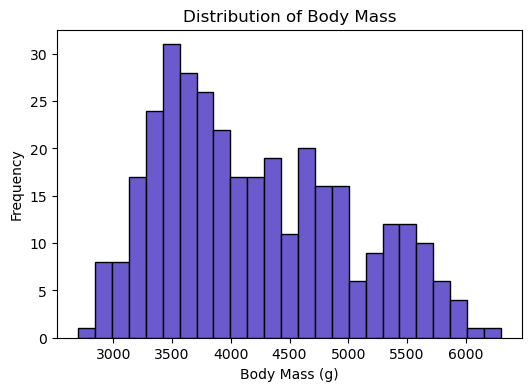

In [8]:
plt.figure(figsize=(6, 4))
plt.hist(df['body_mass_g'].dropna(), bins=25, color='slateblue', edgecolor='black')
plt.title('Distribution of Body Mass')
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.show()

**Guided interpretation questions for any histogram:**
- Is the distribution roughly symmetric, or skewed to one side?
- Is it unimodal (one peak) or does it show multiple peaks (which can hint at subgroups)?
- Are there any extreme values far from the bulk of the data?

> *Example write-up:*
>
> Body mass shows a right-skewed distribution with two visible peaks, suggesting the presence of subgroups within the data (likely different species or sexes) rather than a single homogeneous population. Most penguins weigh between 3,000g and 4,500g, with a smaller cluster extending toward 6,000g. No extreme outliers are visible beyond the natural range of the data.


### 5.2 Categorical Variable: Species


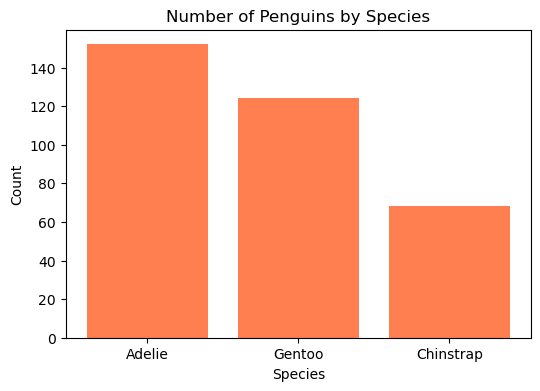

In [9]:
species_counts = df['species'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(species_counts.index, species_counts.values, color='coral')
plt.title('Number of Penguins by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

**Guided interpretation questions for a bar chart of counts:**
- Are the categories roughly balanced, or is one category dominant?
- Could an imbalance affect later analysis (e.g. a machine learning model favoring the majority class)?

> *Example write-up:*
>
> The dataset is moderately imbalanced across species: Adelie penguins are the most common (152 records), followed by Gentoo (124) and Chinstrap (68). This imbalance should be kept in mind for any downstream classification task, as a model could become biased toward predicting the majority class unless this is addressed.


## 6. Bivariate Analysis — Relationships Between Variables

### 6.1 Numeric vs Numeric: Flipper Length vs Body Mass


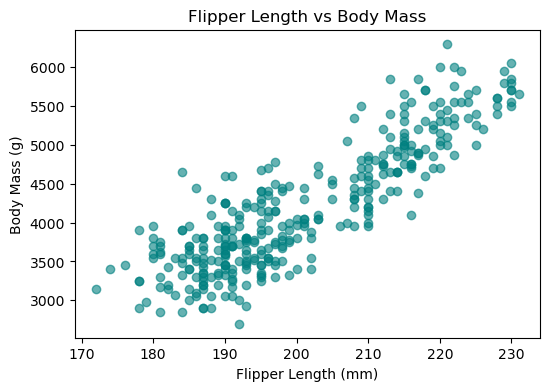

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(df['flipper_length_mm'], df['body_mass_g'], alpha=0.6, color='teal')
plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()


In [11]:
df[['flipper_length_mm', 'body_mass_g']].corr()


,flipper_length_mm,body_mass_g
flipper_length_mm,1.000000,0.871202
body_mass_g,0.871202,1.000000


**Guided interpretation questions for a scatter plot:**
- Is there a visible trend (positive, negative, or none)?
- Is the relationship linear, or does it curve?
- Does the correlation value support what the chart shows visually?

> *Example write-up:*
>
> There is a clear positive relationship between flipper length and body mass (correlation ≈ 0.87): penguins with longer flippers tend to weigh more. The relationship appears roughly linear with some spread, suggesting flipper length could be a useful predictor of body mass, or vice versa, in a regression context.


### 6.2 Numeric vs Categorical: Body Mass by Species


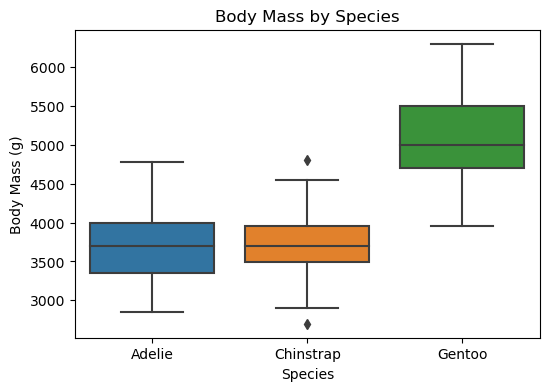

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='species', y='body_mass_g', data=df)
plt.title('Body Mass by Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()


**Guided interpretation questions for a grouped boxplot:**
- Do the categories have clearly different medians, or do they overlap heavily?
- Which category has the most spread (variability)?
- Are there outliers within any specific category?

> *Example write-up:*
>
> Gentoo penguins are visibly heavier than the other two species, with a median body mass around 5,000g compared to roughly 3,700g for Adelie and Chinstrap. Adelie and Chinstrap distributions overlap substantially, meaning body mass alone would not reliably distinguish between these two species. Gentoo also shows a wider spread, indicating more variability in size within that species.


### 6.3 Categorical vs Categorical: Species by Island


In [13]:
species_island = pd.crosstab(df['island'], df['species'])
species_island


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


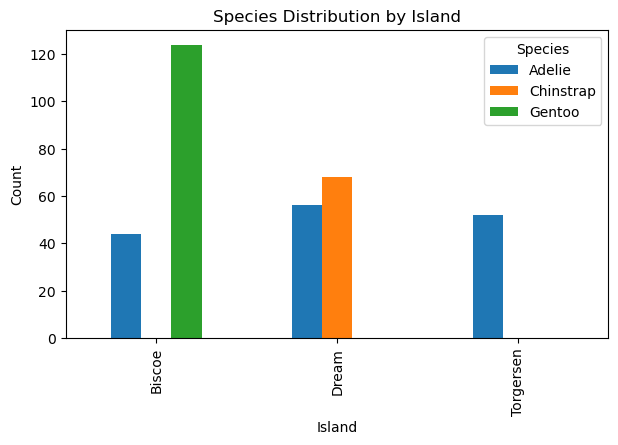

In [14]:
species_island.plot(kind='bar', figsize=(7, 4))
plt.title('Species Distribution by Island')
plt.xlabel('Island')
plt.ylabel('Count')
plt.legend(title='Species')
plt.show()


**Guided interpretation questions for a crosstab / grouped bar chart:**
- Are certain categories only found together (co-occurrence), or evenly spread?
- Does this suggest a relationship between the two categorical variables?

> *Example write-up:*
>
> Species distribution is not uniform across islands: Gentoo penguins are found exclusively on Biscoe Island, while Chinstrap penguins are found only on Dream Island. Adelie penguins are the only species present across all three islands. This strong association suggests that `island` could act as a near-perfect proxy for species in this dataset, which is worth noting if island is ever used as a feature in a predictive model.


## 7. Multivariate View — Combining Multiple Variables


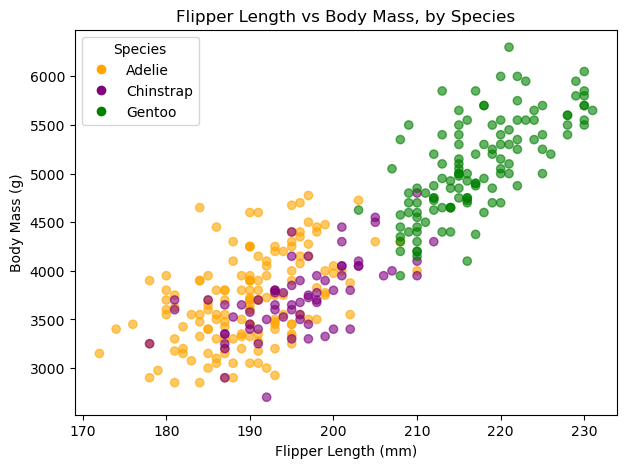

In [15]:
plt.figure(figsize=(7, 5))
species_colors = {'Adelie': 'orange', 'Chinstrap': 'purple', 'Gentoo': 'green'}
colors = df['species'].map(species_colors)

plt.scatter(df['flipper_length_mm'], df['body_mass_g'], c=colors, alpha=0.6)
plt.title('Flipper Length vs Body Mass, by Species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=sp, markerfacecolor=c, markersize=8)
                    for sp, c in species_colors.items()]
plt.legend(handles=legend_elements, title='Species')
plt.show()


> *Example write-up:*
>
> Adding species as a color dimension clarifies the earlier flipper length vs body mass relationship: each species occupies a fairly distinct region of the plot, with Gentoo penguins clustering at higher flipper length and body mass, and Adelie at the lower end. This indicates that the overall positive correlation seen earlier is partly driven by differences *between* species rather than a single unified trend, and that species-specific analysis would likely be more accurate than treating the dataset as one group.


## 8. Writing the Key Insights Section

This is the most important part of any EDA summary — a short, clear list of the findings that matter most, written for someone who has not looked at the charts.

> *Example write-up:*
>
> **Key Insights:**
> 1. Body mass and flipper length are strongly positively correlated (r ≈ 0.87), but this relationship is largely driven by differences between species rather than within a single species.
> 2. Gentoo penguins are significantly heavier and have longer flippers than Adelie and Chinstrap, making body mass a strong distinguishing feature for Gentoo specifically.
> 3. Adelie and Chinstrap penguins overlap substantially in body mass, so this measurement alone would not reliably separate the two.
> 4. Island is almost perfectly associated with species (Gentoo = Biscoe, Chinstrap = Dream), meaning island could unintentionally leak species information if used carelessly as a model feature.
> 5. Missing data is minor (under 4%) and unlikely to bias the analysis if handled with simple imputation or removal.


## 9. Writing the Recommendations Section

> *Example write-up:*
>
> **Recommendations / Next Steps:**
> - Handle missing values in the four affected columns before further analysis (drop or impute, as discussed in Section 2).
> - Treat body mass and flipper length as species-aware features, not a single blanket trend, in any downstream modeling.
> - Be cautious using `island` as a predictive feature if the goal is species-independent modeling, since it may act as a proxy for the target.
> - Consider bill length and bill depth (not yet explored above) as additional candidate features to separate Adelie and Chinstrap, since body mass alone is insufficient.


## 10. Hands-on Practice Exercise 1 — Interpret a Given Chart

Run the cell below, then write a 3-4 sentence interpretation (in a markdown cell) following the guided questions style used above: what does the chart show, is there a pattern, and what might it mean?


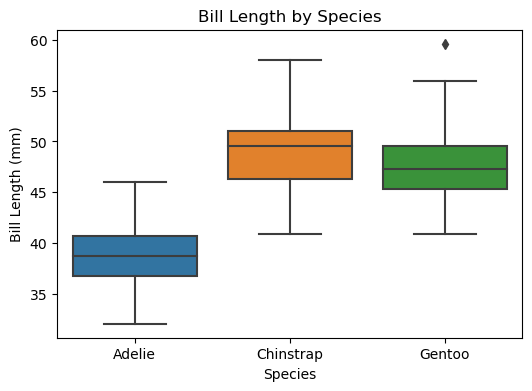

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='species', y='bill_length_mm', data=df)
plt.title('Bill Length by Species')
plt.xlabel('Species')
plt.ylabel('Bill Length (mm)')
plt.show()


*Write your interpretation here:*



## 11. Hands-on Practice Exercise 2 — Generate and Interpret

1. Create a histogram of `bill_depth_mm`
2. Create a scatter plot of `bill_length_mm` vs `bill_depth_mm`, colored by `species`
3. For each chart, write a short interpretation using the guided questions from Sections 5 and 6


In [17]:
# Write your solution here



*Write your interpretations here:*



## 12. Hands-on Practice Exercise 3 — Write a Full EDA Summary

Using the `penguins` dataset (or a dataset of your choice), write a complete EDA summary following the 6-part structure from Section 2:

1. Dataset Overview
2. Data Quality Notes
3. Univariate Analysis (at least 2 charts with interpretation)
4. Bivariate Analysis (at least 2 charts with interpretation)
5. Key Insights (3-5 bullet points)
6. Recommendations / Next Steps

Use a mix of code cells (for charts) and markdown cells (for your written analysis), just like the structure used throughout this notebook.


In [18]:
# Write your code here



*Write your full EDA summary here, using markdown cells to structure each section.*



## Key Terms Glossary

| Term | Meaning |
|---|---|
| EDA (Exploratory Data Analysis) | The process of investigating a dataset before formal modeling |
| Univariate analysis | Examining a single variable at a time |
| Bivariate analysis | Examining the relationship between two variables |
| Multivariate view | Examining relationships across three or more variables at once |
| Skewness | Asymmetry in the shape of a distribution |
| Correlation | A numeric measure of the strength/direction of a linear relationship |
| Crosstab | A table showing counts across two categorical variables |
| Key insights | The short list of most important, decision-relevant findings |


## Common Mistakes to Avoid

- Describing a chart ("this is a bar chart showing counts by species") instead of interpreting it ("Adelie is the most common species, roughly double Chinstrap")
- Writing an insight without checking whether the underlying numbers actually support it (e.g. claiming a "strong trend" without checking the correlation value)
- Skipping the data quality section and jumping straight to charts
- Writing key insights as a summary of every chart made, instead of the 3-5 findings that matter most
- Interpreting a scatter plot's correlation as causation, without noting that correlation does not imply cause and effect
- Forgetting to connect insights to a "so what" — i.e., what should be done differently because of this finding


## Homework / Practice Assignment

1. Choose any dataset (can be `sns.load_dataset('titanic')`, `sns.load_dataset('diamonds')`, or your own CSV file)
2. Produce at least 4 different charts covering univariate and bivariate analysis
3. Write a complete EDA summary using the 6-part structure covered in this notebook
4. Make sure every chart has a written interpretation directly beneath it, not just a title
5. Come prepared with 2 questions/doubts for the next session, which begins Module 5: Supervised Machine Learning
